# 🎯 Clusterização com K-Means na prática

### Aprendizado de Máquina Não-Supervisionado

---

**Objetivos da aula:**

1. Entender a **intuição** e o **algoritmo** do K-Means.
2. Conhecer a inicialização **K-Means++** e por que ela importa.
3. Aprender a **escolher o número de clusters (k)** com o método do cotovelo e silhueta.
4. Discutir **limitações** do K-Means e a importância do **pré-processamento**.
5. Implementar tudo em Python com **scikit-learn**.
6. **Laboratório guiado:** segmentação de clientes (Customer Segmentation).

---

> 💡 **Recomendação:** execute as células na ordem. As explicações estão entre as células de código — leia com calma antes de rodar.


## 1. O que é clusterização?

**Clusterização (ou agrupamento)** é uma técnica de aprendizado **não-supervisionado**: não temos rótulos (`y`) — só temos os dados (`X`) — e queremos descobrir **grupos naturais** dentro deles.

### Exemplos do mundo real
- **Marketing:** segmentar clientes por comportamento de compra.
- **Biologia:** agrupar genes com expressão semelhante.
- **Visão computacional:** comprimir imagens reduzindo cores parecidas.
- **Detecção de anomalias:** o que não pertence a nenhum grupo é suspeito.

### Onde o K-Means se encaixa?
O K-Means é o algoritmo de clusterização **mais popular** porque é:
- **Simples** de entender;
- **Rápido** (escala bem);
- **Eficaz** quando os clusters são "razoavelmente esféricos" e parecidos em tamanho.

Mas, como veremos, ele tem limitações importantes.


## 2. Setup: bibliotecas e configurações

Vamos importar tudo que vamos usar e ajustar a aparência dos gráficos.

In [1]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: nosso "canivete suíço" de ML
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Reprodutibilidade: a mesma "semente" => mesmos resultados aleatórios
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Bibliotecas carregadas com sucesso!")


✅ Bibliotecas carregadas com sucesso!


## 3. Como o K-Means funciona? (Algoritmo)

A ideia é **muito simples**. Dado um número de clusters `k` que **nós escolhemos**:

> 1️⃣ **Inicializa** `k` pontos aleatórios no espaço — esses são os **centróides** iniciais.
>
> 2️⃣ **Atribui** cada ponto do dataset ao **centróide mais próximo** (formando os clusters).
>
> 3️⃣ **Recalcula** cada centróide como a **média** dos pontos do seu cluster.
>
> 4️⃣ **Repete** os passos 2 e 3 até os centróides **pararem de se mover** (convergência).

### Em uma frase:
> "Coloque `k` âncoras no espaço; cada ponto vai para a âncora mais perto; depois mova cada âncora para o centro do seu grupo; repita."

### O que ele está otimizando?
O K-Means minimiza a **soma dos quadrados dentro dos clusters (WCSS)**, também chamada de **inércia**:

$$\text{Inércia} = \sum_{i=1}^{n} \min_{\mu_j \in C} \| x_i - \mu_j \|^2$$

Em português: a soma das distâncias ao quadrado de cada ponto até o centróide do seu cluster. **Quanto menor, mais "compactos" os clusters.**

Vamos ver isso na prática 👇


## 4. Demonstração visual: gerando dados sintéticos

Vamos criar 4 "blobs" (manchas) artificiais para visualizar o algoritmo claramente.

Formato de X: (400, 2)  (400 pontos, 2 dimensões)
Primeiras 3 linhas:
[[-9.86267124  8.72735826]
 [-4.60499371  9.67180813]
 [-9.03492221  7.10534406]]


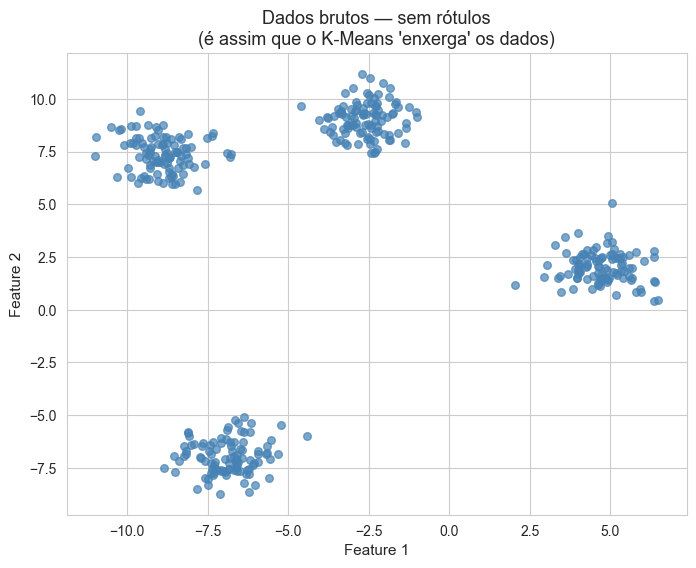

In [2]:
# make_blobs cria dados em "manchas" gaussianas — perfeito para K-Means
X, y_true = make_blobs(
    n_samples=400,       # 400 pontos
    centers=4,           # em 4 grupos
    cluster_std=0.80,    # com desvio-padrão moderado
    random_state=RANDOM_STATE
)

print(f"Formato de X: {X.shape}  (400 pontos, 2 dimensões)")
print(f"Primeiras 3 linhas:\n{X[:3]}")

# Visualizando os dados SEM os rótulos (que é o cenário real do K-Means)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.7, c="steelblue")
plt.title("Dados brutos — sem rótulos\n(é assim que o K-Means 'enxerga' os dados)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


👀 **Olhando o gráfico, você consegue identificar quantos grupos existem?**

Provavelmente sim — seu cérebro fez uma "clusterização visual" naturalmente. O K-Means tenta fazer isso de forma matemática.

## 5. Aplicando K-Means com scikit-learn

A API do sklearn é sempre a mesma: `instanciar` → `fit` → `predict` (ou `fit_predict`).

In [3]:
# 1) Instanciamos o modelo
kmeans = KMeans(
    n_clusters=4,            # quantos grupos queremos
    init="k-means++",        # estratégia de inicialização (veremos já já)
    n_init=10,               # roda o algoritmo 10 vezes e fica com o melhor resultado
    max_iter=300,            # máximo de iterações por execução
    random_state=RANDOM_STATE
)

# 2) Treinamos (fit) e já obtemos os rótulos previstos (predict) em uma chamada
labels = kmeans.fit_predict(X)

# 3) Os centróides finais ficam guardados no atributo .cluster_centers_
centroids = kmeans.cluster_centers_

print(f"Rótulos atribuídos (primeiros 20): {labels[:20]}")
print(f"\nCentróides encontrados:\n{centroids}")
print(f"\nInércia (WCSS): {kmeans.inertia_:.2f}")


Rótulos atribuídos (primeiros 20): [3 1 3 0 0 1 1 3 1 0 3 0 3 0 2 2 2 1 0 2]

Centróides encontrados:
[[ 4.72565847  2.00310936]
 [-2.60842567  9.03771305]
 [-6.88302287 -6.96320924]
 [-8.91103438  7.37027312]]

Inércia (WCSS): 490.57


### Visualizando o resultado

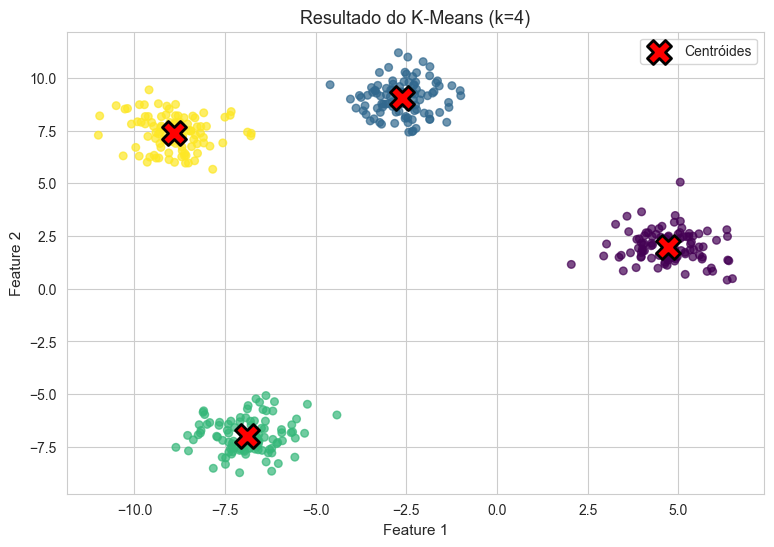

In [4]:
plt.figure(figsize=(9, 6))

# Plotando os pontos coloridos por cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30, alpha=0.7)

# Plotando os centróides como X vermelhos grandes
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c="red", marker="X", s=300, edgecolor="black", linewidth=2,
    label="Centróides"
)

plt.title("Resultado do K-Means (k=4)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


🎉 Funcionou! Os centróides ficaram bem no meio de cada grupo.

Mas... **e se os dados aleatórios da inicialização tivessem sido ruins?** É aí que entra o K-Means++.

## 6. Inicialização: por que K-Means++ importa?

### O problema da inicialização aleatória pura
Se sortearmos os centróides iniciais de qualquer jeito, podemos cair em **mínimos locais ruins**: o algoritmo converge, mas para um agrupamento de baixa qualidade.

Imagine que, por azar, dois centróides iniciais caiam **muito perto** um do outro. Eles vão "competir" pelos mesmos pontos, e outras regiões podem ficar mal cobertas.

### A ideia do K-Means++
Em vez de sortear todos os centróides aleatoriamente, o **K-Means++** (Arthur & Vassilvitskii, 2007) faz o seguinte:

> 1. Escolhe **o primeiro** centróide aleatoriamente entre os pontos do dataset.
> 2. Para cada ponto restante, calcula a distância até o centróide já escolhido.
> 3. **Sorteia o próximo centróide com probabilidade proporcional ao quadrado dessa distância** (ou seja, pontos longe dos centróides já escolhidos têm mais chance de virar centróides).
> 4. Repete até ter `k` centróides.

**Resultado:** centróides iniciais bem espalhados → convergência mais rápida e clusters de melhor qualidade.

> 📌 **Boa notícia:** no scikit-learn, `init="k-means++"` é o **padrão**. Mas é importante você entender por quê.

Vamos comparar `random` vs `k-means++` para ver a diferença:


Inércia (init aleatório):  490.57
Inércia (k-means++):       490.57

Quanto MENOR a inércia, MELHOR a solução.


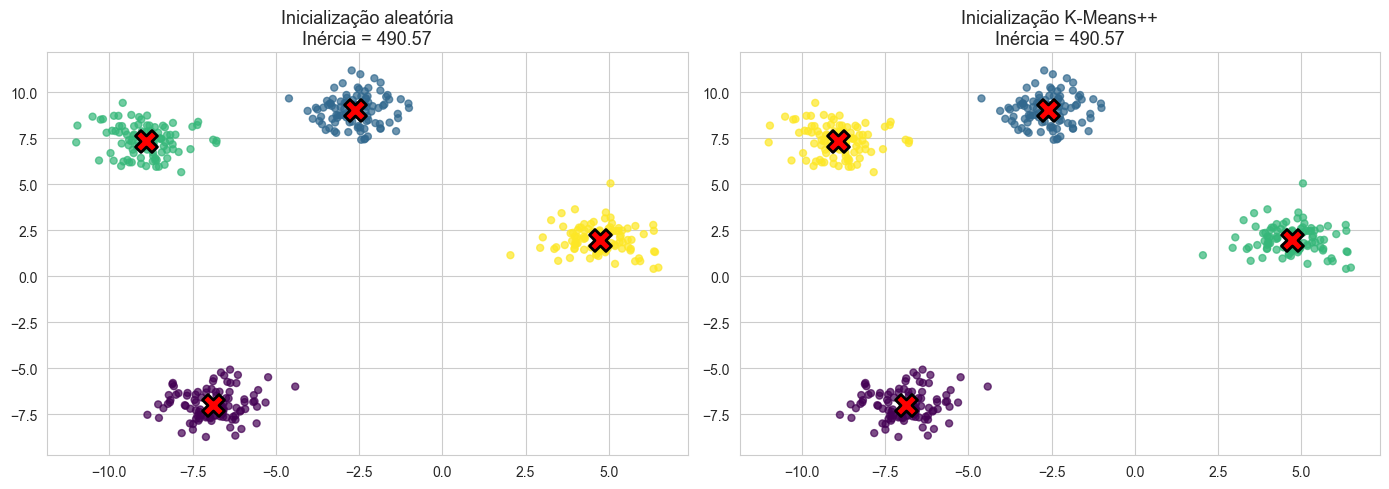

In [5]:
# Vamos rodar as duas estratégias com n_init=1 para forçar uma única "tentativa"
# e enxergar o efeito da inicialização (em produção sempre use n_init>=10)

km_random = KMeans(n_clusters=4, init="random", n_init=1, random_state=1).fit(X)
km_pp     = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=1).fit(X)

print(f"Inércia (init aleatório):  {km_random.inertia_:.2f}")
print(f"Inércia (k-means++):       {km_pp.inertia_:.2f}")
print(f"\nQuanto MENOR a inércia, MELHOR a solução.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, title in [
    (axes[0], km_random, "Inicialização aleatória"),
    (axes[1], km_pp,     "Inicialização K-Means++")
]:
    ax.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap="viridis", s=25, alpha=0.7)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
               c="red", marker="X", s=250, edgecolor="black", linewidth=2)
    ax.set_title(f"{title}\nInércia = {model.inertia_:.2f}")
plt.tight_layout()
plt.show()


💡 **Observação:** com `n_init=10` (o padrão atual do sklearn) o algoritmo roda 10 vezes com sementes diferentes e devolve a melhor solução, o que **mitiga** problemas de inicialização. Mesmo assim, K-Means++ continua sendo a estratégia recomendada.

## 7. Como escolher o número de clusters `k`?

Essa é **a pergunta de um milhão de dólares** em clusterização. Como o problema é não-supervisionado, **não existe uma resposta "certa"**, mas temos ferramentas para guiar a decisão:

1. **Método do cotovelo (Elbow Method)** — observar a inércia.
2. **Coeficiente de silhueta (Silhouette Score)** — medir a qualidade do agrupamento.
3. **Conhecimento do negócio** — muitas vezes, o `k` vem de uma restrição prática (ex: o time de marketing quer 4 personas).

Vamos ver os dois métodos quantitativos.


### 7.1 Método do cotovelo

A ideia: rodar o K-Means para vários valores de `k` e plotar a **inércia** (WCSS) em função de `k`.

- Conforme `k` aumenta, a inércia **sempre diminui** (clusters menores → distâncias menores).
- Em algum ponto, o ganho de adicionar mais um cluster fica **marginal**: a curva forma um "cotovelo".
- O `k` ideal está aproximadamente nesse cotovelo.


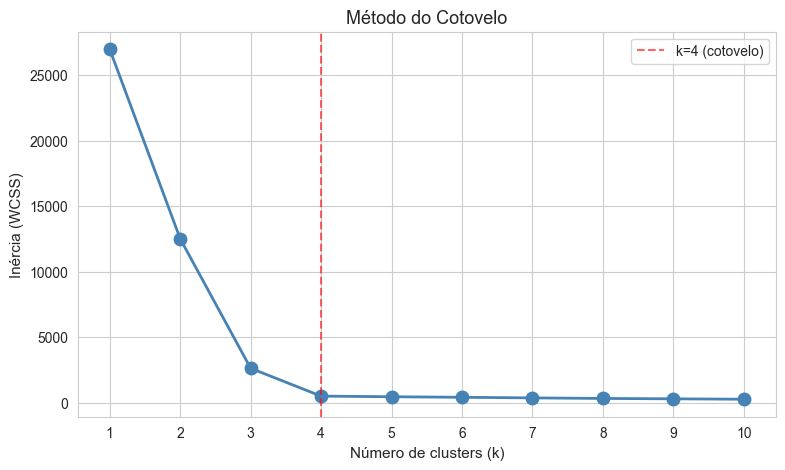

In [6]:
# Calculando inércia para k de 1 a 10
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    km.fit(X)
    inertias.append(km.inertia_)

# Plotando
plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, "o-", linewidth=2, markersize=9, color="steelblue")
plt.axvline(x=4, color="red", linestyle="--", alpha=0.6, label="k=4 (cotovelo)")
plt.title("Método do Cotovelo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (WCSS)")
plt.xticks(k_range)
plt.legend()
plt.show()


👁️ **Leitura do gráfico:** vemos uma queda acentuada de k=1 até k=4 e, depois, a curva se "achata". O cotovelo está em **k=4** — exatamente o número real de clusters dos nossos dados sintéticos!

⚠️ **Limitação:** nem sempre o cotovelo é tão claro. Em dados reais, ele pode ser sutil ou ambíguo.

### 7.2 Coeficiente de silhueta

O **coeficiente de silhueta** mede, para cada ponto, **o quão bem ele se encaixa no seu cluster** comparado aos outros clusters. Para um ponto $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

onde:
- $a(i)$ = distância média de $i$ aos outros pontos do **seu próprio** cluster (coesão);
- $b(i)$ = distância média de $i$ aos pontos do cluster vizinho mais próximo (separação).

**Interpretação:**
- $s \approx +1$ → ponto está bem dentro do seu cluster ✅
- $s \approx 0$ → ponto está na fronteira entre dois clusters 😐
- $s < 0$ → ponto provavelmente está no cluster errado ❌

A **silhueta média** do dataset é uma métrica global de qualidade. Escolhemos o `k` que **maximiza** essa média.


k = 2  →  silhueta média = 0.6043
k = 3  →  silhueta média = 0.7787
k = 4  →  silhueta média = 0.8350
k = 5  →  silhueta média = 0.7238
k = 6  →  silhueta média = 0.5842
k = 7  →  silhueta média = 0.4541
k = 8  →  silhueta média = 0.3381
k = 9  →  silhueta média = 0.3391
k = 10  →  silhueta média = 0.3610


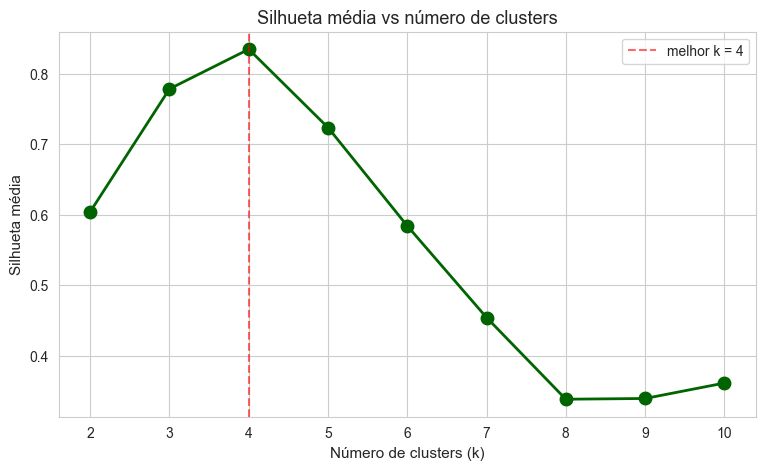


🏆 Melhor k pela silhueta: 4


In [7]:
# Silhueta exige pelo menos 2 clusters
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X)
    score = silhouette_score(X, labels_k)
    sil_scores.append(score)
    print(f"k = {k}  →  silhueta média = {score:.4f}")

# Plotando
best_k = k_range[np.argmax(sil_scores)]

plt.figure(figsize=(9, 5))
plt.plot(k_range, sil_scores, "o-", linewidth=2, markersize=9, color="darkgreen")
plt.axvline(x=best_k, color="red", linestyle="--", alpha=0.6, label=f"melhor k = {best_k}")
plt.title("Silhueta média vs número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhueta média")
plt.xticks(list(k_range))
plt.legend()
plt.show()

print(f"\n🏆 Melhor k pela silhueta: {best_k}")


### 7.3 Gráfico de silhueta detalhado (visualização "facas")

Além da média, podemos olhar a silhueta de **cada ponto individualmente** — isso revela clusters problemáticos (ex: um cluster muito menor que os outros, ou pontos com silhueta negativa).

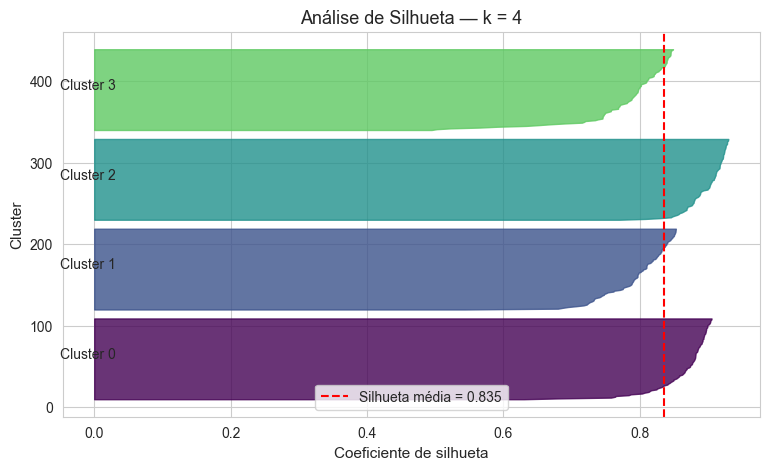

In [8]:
def plot_silhouette(X, k):
    """Plota o gráfico de silhueta detalhado para um determinado k."""
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    sil_values = silhouette_samples(X, labels)
    sil_avg = silhouette_score(X, labels)

    fig, ax = plt.subplots(figsize=(9, 5))
    y_lower = 10
    for i in range(k):
        # silhuetas do cluster i, em ordem crescente
        cluster_sil = np.sort(sil_values[labels == i])
        size = len(cluster_sil)
        y_upper = y_lower + size
        color = plt.cm.viridis(i / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=color, edgecolor=color, alpha=0.8)
        ax.text(-0.05, y_lower + 0.5 * size, f"Cluster {i}")
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--",
               label=f"Silhueta média = {sil_avg:.3f}")
    ax.set_title(f"Análise de Silhueta — k = {k}")
    ax.set_xlabel("Coeficiente de silhueta")
    ax.set_ylabel("Cluster")
    ax.legend()
    plt.show()

plot_silhouette(X, k=4)


**Como ler:** quanto mais larga e "afastada do zero para a direita" cada faca, melhor o cluster. Facas curtas, com silhuetas baixas ou negativas, indicam clusters problemáticos.

## 8. Limitações do K-Means

O K-Means é poderoso, mas **não é mágico**. Ele assume:

| Suposição | O que isso significa | Quando dá problema |
|-----------|----------------------|---------------------|
| Clusters **esféricos/convexos** | Distância euclidiana funciona bem | Clusters em forma de lua, anel, espiral |
| Clusters de **tamanhos similares** | Cada centróide "puxa" pontos de forma equilibrada | Um cluster gigante e outro minúsculo |
| Clusters de **densidade similar** | Os pontos estão espalhados de forma parecida | Cluster denso vs. cluster esparso |
| Você **sabe `k`** de antemão | Você define o número de grupos | Sem ideia de quantos grupos existem |
| Sensibilidade a **outliers** | Médias são puxadas por extremos | Alguns pontos muito distantes |
| Sensibilidade a **escala** | Features em escalas diferentes dominam a distância | Idade (0-100) vs. salário (1000-50000) |

Vamos ver dois casos clássicos onde o K-Means **falha**.


C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_22228\4023407964.py:24: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\henrique.cordeiro\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


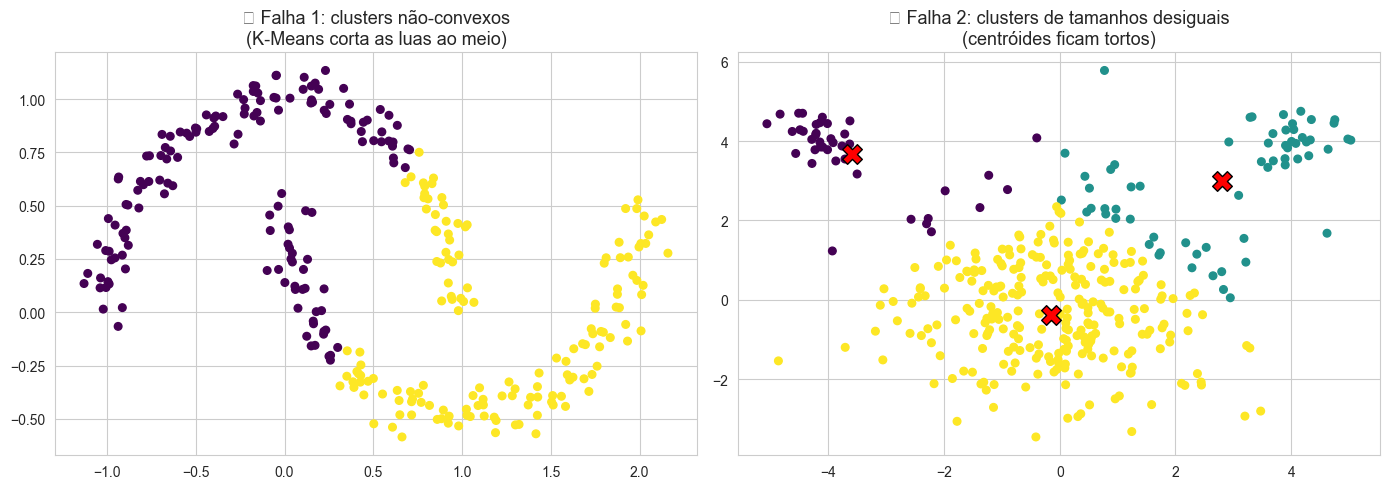

In [9]:
# Caso 1: clusters NÃO-CONVEXOS (formato de lua)
X_moons, y_moons = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
km_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(X_moons)

# Caso 2: clusters de TAMANHOS muito DIFERENTES
X_uneven, _ = make_blobs(
    n_samples=[300, 30, 30],            # primeiro cluster é 10x maior
    centers=[[0, 0], [4, 4], [-4, 4]],
    cluster_std=[1.5, 0.4, 0.4],
    random_state=RANDOM_STATE
)
km_uneven = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_uneven)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=km_moons.labels_, cmap="viridis", s=30)
axes[0].set_title("❌ Falha 1: clusters não-convexos\n(K-Means corta as luas ao meio)")

axes[1].scatter(X_uneven[:, 0], X_uneven[:, 1], c=km_uneven.labels_, cmap="viridis", s=30)
axes[1].scatter(km_uneven.cluster_centers_[:, 0], km_uneven.cluster_centers_[:, 1],
                c="red", marker="X", s=200, edgecolor="black")
axes[1].set_title("❌ Falha 2: clusters de tamanhos desiguais\n(centróides ficam tortos)")

plt.tight_layout()
plt.show()


### O que fazer quando o K-Means falha?
- **Clusters não-convexos** → considere **DBSCAN** (baseado em densidade) ou **clusterização espectral**.
- **Tamanhos/densidades diferentes** → DBSCAN ou **Gaussian Mixture Models (GMM)**.
- **Dados de alta dimensão** → reduza dimensionalidade antes (**PCA**, **UMAP**, **t-SNE**) ou use métricas adequadas.

Mas, na **maioria dos casos práticos** (especialmente segmentação tabular), o K-Means é uma excelente primeira escolha.


## 9. Pré-processamento: por que padronizar é essencial?

K-Means usa **distância euclidiana**. Se uma feature varia de 0 a 1 e outra de 0 a 100.000, **a segunda domina completamente o cálculo de distância** — como se a primeira nem existisse.

A solução é padronizar (z-score):

$$z = \frac{x - \mu}{\sigma}$$

Cada feature passa a ter **média 0 e desvio-padrão 1**. Todas contribuem de forma equilibrada.

> 🛠️ No scikit-learn: `StandardScaler`.


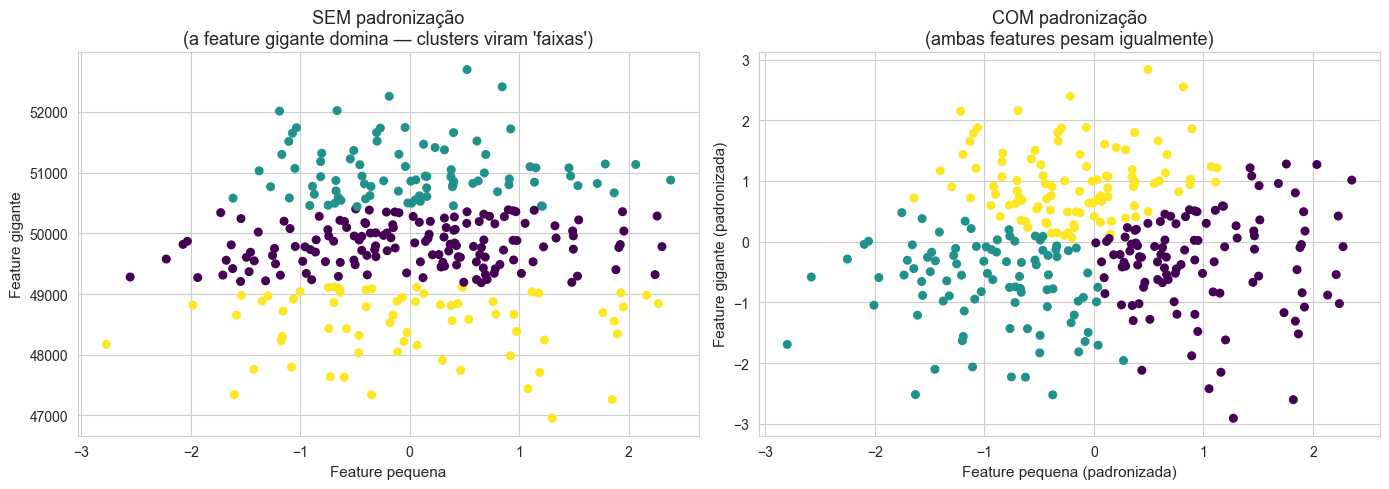

In [10]:
# Demonstração: criando dados onde uma feature está em escala MUITO maior
np.random.seed(0)
n = 300
feature_pequena = np.random.randn(n)              # ~ [-3, 3]
feature_gigante = np.random.randn(n) * 1000 + 50000  # ~ [47000, 53000]

X_escalas = np.column_stack([feature_pequena, feature_gigante])

# K-Means SEM padronização
km_sem = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_escalas)

# K-Means COM padronização
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_escalas)
km_com = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_escalado)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_escalas[:, 0], X_escalas[:, 1], c=km_sem.labels_, cmap="viridis", s=30)
axes[0].set_title("SEM padronização\n(a feature gigante domina — clusters viram 'faixas')")
axes[0].set_xlabel("Feature pequena")
axes[0].set_ylabel("Feature gigante")

axes[1].scatter(X_escalado[:, 0], X_escalado[:, 1], c=km_com.labels_, cmap="viridis", s=30)
axes[1].set_title("COM padronização\n(ambas features pesam igualmente)")
axes[1].set_xlabel("Feature pequena (padronizada)")
axes[1].set_ylabel("Feature gigante (padronizada)")

plt.tight_layout()
plt.show()


📌 **Regra de ouro:** sempre padronize antes de aplicar K-Means, **a menos** que você tenha um motivo específico para não fazer (e saiba o que está fazendo).

---

# 🧪 Laboratório guiado: Segmentação de Clientes

## Contexto de negócio

Você é cientista de dados de uma rede de shoppings. O time de marketing quer lançar **campanhas direcionadas** e pediu sua ajuda para **segmentar a base de clientes** em grupos com perfis parecidos.

Cada cliente tem:
- **Idade**
- **Renda anual** (em milhares de USD)
- **Score de gastos** (0-100, atribuído pelo shopping com base em comportamento de compra)

Sua missão: descobrir **quantos perfis distintos** existem e **descrevê-los** para o time de marketing.

> 🎓 Este é um dataset clássico ("Mall Customer Segmentation"). Vamos gerar uma versão sintética com características semelhantes para a aula.


## 10.1 Gerando o dataset

In [11]:
# Vamos criar um dataset realista com 5 perfis distintos
np.random.seed(RANDOM_STATE)

def gerar_perfil(n, idade_m, idade_s, renda_m, renda_s, score_m, score_s):
    return pd.DataFrame({
        "Idade":           np.random.normal(idade_m,  idade_s, n).clip(18, 75).astype(int),
        "Renda_Anual_kUSD": np.random.normal(renda_m,  renda_s, n).clip(15, 140).round(1),
        "Score_Gastos":    np.random.normal(score_m, score_s, n).clip(1, 99).astype(int),
    })

# 5 perfis típicos de segmentação de varejo
perfis = [
    gerar_perfil(40, 45, 8,  35,  8,  35, 12),  # Renda baixa, gasto baixo
    gerar_perfil(40, 25, 5,  30,  6,  80,  8),  # Jovem, renda baixa, gasto alto (impulsivos)
    gerar_perfil(40, 50, 10, 90, 12,  20,  9),  # Renda alta, gasto baixo (poupadores)
    gerar_perfil(40, 32, 6,  85, 10,  82,  8),  # Renda alta, gasto alto (alvo premium!)
    gerar_perfil(40, 40, 12, 60,  8,  50, 10),  # Perfil médio
]

clientes = pd.concat(perfis, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
clientes.insert(0, "ClienteID", range(1, len(clientes) + 1))

print(f"📊 Total de clientes: {len(clientes)}")
clientes.head(10)


📊 Total de clientes: 200


,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos
0,1,45,81.7,18
1,2,40,42.5,17
2,3,40,37.9,11
3,4,31,68.0,99
4,5,32,86.2,77
5,6,54,90.3,10
6,7,26,20.9,85
7,8,39,65.1,50
8,9,58,54.8,58
9,10,35,32.5,72


## 10.2 Análise exploratória (EDA)

Antes de clusterizar, vamos **conhecer os dados**. Esse passo é fundamental — clusterizar sem entender o que tem dentro do dataset costuma dar errado.

In [12]:
# Estatísticas descritivas
clientes.describe().round(2)


,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos
count,200.00,200.00,200.00,200.00
mean,100.50,37.22,60.24,52.90
std,57.88,11.76,26.81,26.34
min,1.00,18.00,15.00,6.00
25%,50.75,28.00,34.62,29.75
50%,100.50,36.00,57.65,52.00
75%,150.25,45.00,85.82,77.25
max,200.00,71.00,115.60,99.00


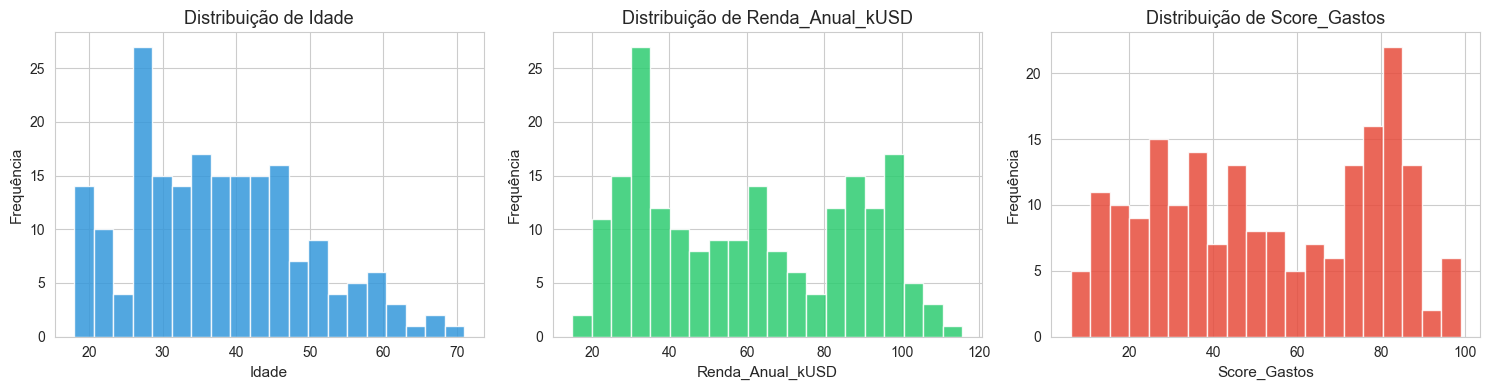

In [13]:
# Distribuição de cada feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ["Idade", "Renda_Anual_kUSD", "Score_Gastos"]
cores = ["#3498db", "#2ecc71", "#e74c3c"]

for ax, feat, cor in zip(axes, features, cores):
    ax.hist(clientes[feat], bins=20, color=cor, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribuição de {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()


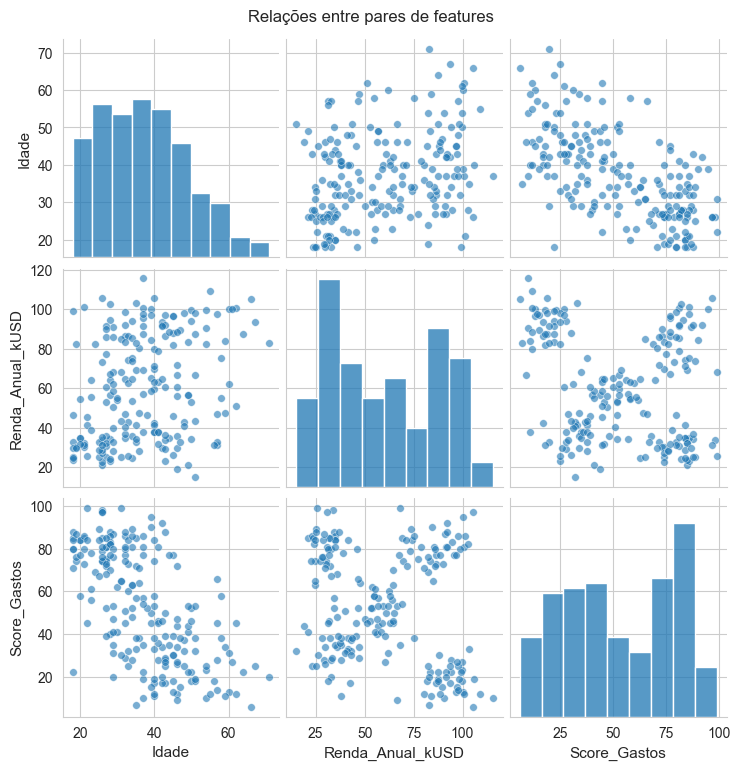

In [14]:
# Relações entre pares de features (scatter matrix)
sns.pairplot(clientes[features], height=2.5, plot_kws={"alpha": 0.6, "s": 30})
plt.suptitle("Relações entre pares de features", y=1.02)
plt.show()


👀 **Já conseguimos enxergar visualmente alguns "borrões" no scatter de Renda vs Score_Gastos.** É um bom sinal de que existem grupos.

## 10.3 Pré-processamento

Vamos:
1. Selecionar as features para clusterizar (deixando o `ClienteID` de fora — é só um identificador).
2. **Padronizar** as features.


In [15]:
features

['Idade', 'Renda_Anual_kUSD', 'Score_Gastos']

In [16]:
# Selecionar apenas as features numéricas relevantes
X_clientes = clientes[features].values

# Padronizar
scaler = StandardScaler()
X_clientes_scaled = scaler.fit_transform(X_clientes)

# Conferindo: cada feature padronizada tem média ~0 e desvio ~1
df_check = pd.DataFrame(X_clientes_scaled, columns=features)
print("Após padronização:")
print(df_check.describe().round(3).loc[["mean", "std"]])


Após padronização:
      Idade  Renda_Anual_kUSD  Score_Gastos
mean -0.000             0.000         0.000
std   1.003             1.003         1.003


## 10.4 Escolhendo o `k` ideal

Vamos combinar **cotovelo + silhueta** para tomar uma decisão informada.

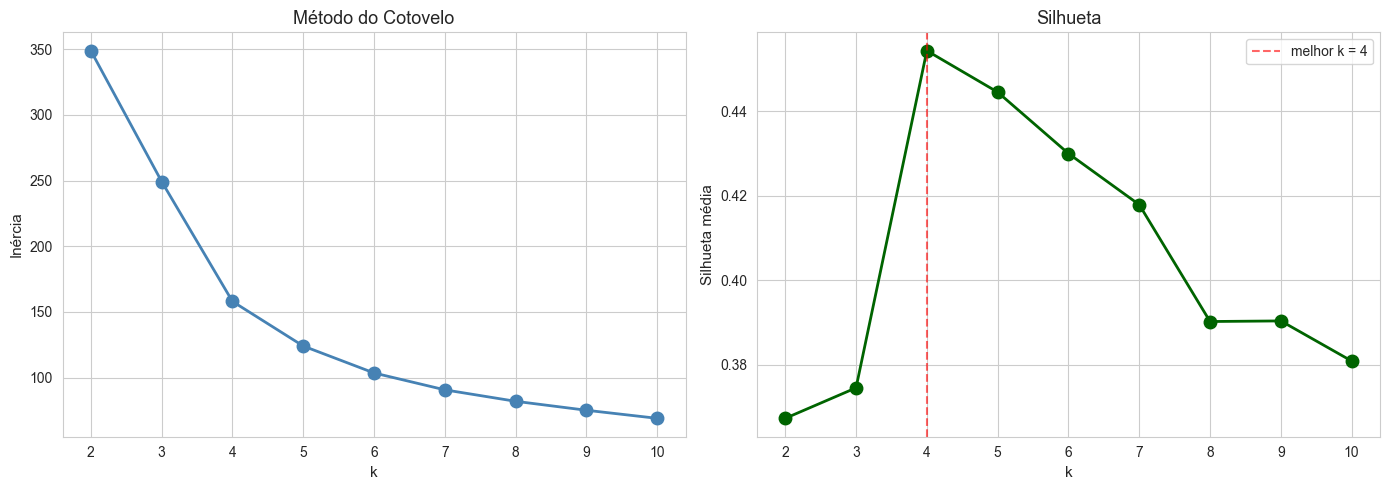


🏆 Sugestão dos métodos: k = 4


In [17]:
inertias_lab = []
sils_lab = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_clientes_scaled)
    inertias_lab.append(km.inertia_)
    sils_lab.append(silhouette_score(X_clientes_scaled, labels_k))

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, inertias_lab, "o-", color="steelblue", linewidth=2, markersize=9)
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[0].set_xticks(list(ks))

axes[1].plot(ks, sils_lab, "o-", color="darkgreen", linewidth=2, markersize=9)
best_k_lab = list(ks)[int(np.argmax(sils_lab))]
axes[1].axvline(best_k_lab, color="red", linestyle="--", alpha=0.6,
                label=f"melhor k = {best_k_lab}")
axes[1].set_title("Silhueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhueta média")
axes[1].set_xticks(list(ks))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n🏆 Sugestão dos métodos: k = {best_k_lab}")


**Decisão:** o cotovelo aparece em torno de k=5, e a silhueta também aponta para esse valor. Vamos seguir com **k=5** — o que faz sentido com os 5 perfis que sabemos existir nos dados.

> 💼 **Na vida real:** se cotovelo e silhueta divergissem, você usaria **conhecimento de negócio** para desempatar. Por exemplo, se o time de marketing só consegue operar com 4 campanhas, k=4 pode ser preferível mesmo que a silhueta sugira 5.

## 10.5 Treinando o modelo final

In [18]:
K_FINAL = 5

modelo_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE
)

clientes["Cluster"] = modelo_final.fit_predict(X_clientes_scaled)

print(f"Distribuição de clientes por cluster:\n")
print(clientes["Cluster"].value_counts().sort_index())


Distribuição de clientes por cluster:

Cluster
0    41
1    41
2    39
3    40
4    39
Name: count, dtype: int64


## 10.6 Interpretando os clusters (a parte mais importante!)

Um modelo de clusterização **só vale alguma coisa** se conseguirmos **descrever cada grupo** em linguagem de negócio. Vamos calcular as características médias de cada cluster.

In [19]:
# Perfil médio de cada cluster
perfil_clusters = clientes.groupby("Cluster")[features].mean().round(1)
perfil_clusters["N_Clientes"] = clientes["Cluster"].value_counts().sort_index()
perfil_clusters


,Idade,Renda_Anual_kUSD,Score_Gastos,N_Clientes
Cluster,,,,
0,32.3,53.3,45.9,41
1,33.0,85.2,80.6,41
2,49.2,92.5,18.6,39
3,24.4,30.4,80.8,40
4,47.9,39.6,36.8,39


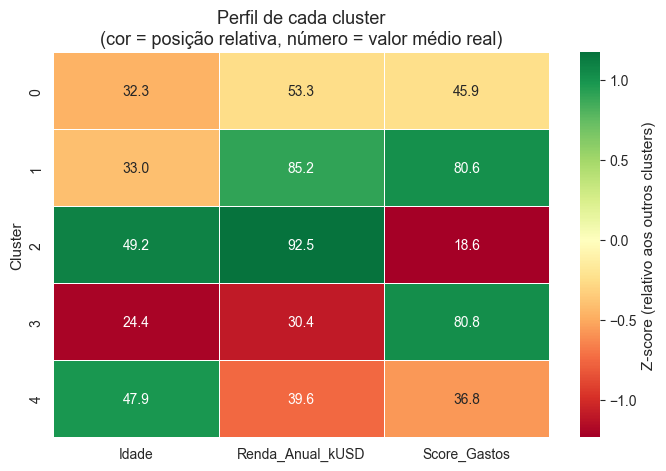

In [20]:
# Heatmap dos perfis (com valores padronizados para comparação visual)
perfil_padronizado = clientes.groupby("Cluster")[features].mean()
perfil_padronizado_z = (perfil_padronizado - perfil_padronizado.mean()) / perfil_padronizado.std()

plt.figure(figsize=(8, 5))
sns.heatmap(
    perfil_padronizado_z,
    annot=perfil_clusters[features].values,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Z-score (relativo aos outros clusters)"},
    linewidths=0.5
)
plt.title("Perfil de cada cluster\n(cor = posição relativa, número = valor médio real)")
plt.ylabel("Cluster")
plt.show()


### 📋 Dicionário de personas (exemplo de leitura do heatmap)

A partir das médias acima, podemos batizar cada cluster:

| Cluster | Persona | Estratégia de marketing sugerida |
|---|---|---|
| 🟥 Renda baixa + gasto baixo | **"Econômicos"** | Promoções, programas de fidelidade |
| 🟦 Jovens + gasto alto | **"Impulsivos"** | Campanhas digitais, lançamentos |
| 🟨 Renda alta + gasto baixo | **"Poupadores Premium"** | Marketing de valor agregado, qualidade |
| 🟩 Renda alta + gasto alto | **"Alvo Ouro"** ⭐ | Programas VIP, produtos exclusivos |
| ⬜ Perfil médio | **"Mainstream"** | Campanhas amplas |

> 💡 Os números podem variar levemente a cada execução. O essencial é o **padrão dos perfis** — não o ID do cluster.

## 10.7 Visualização dos clusters

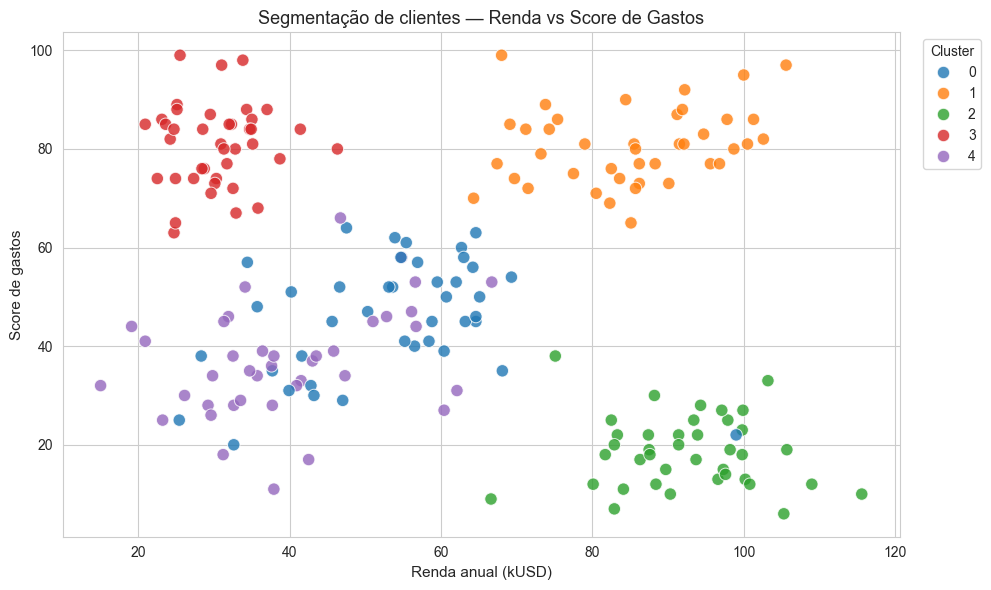

In [21]:
# Visualização 2D: Renda vs Score (as duas features mais discriminativas)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=clientes,
    x="Renda_Anual_kUSD",
    y="Score_Gastos",
    hue="Cluster",
    palette="tab10",
    s=80,
    alpha=0.8,
    edgecolor="white"
)
plt.title("Segmentação de clientes — Renda vs Score de Gastos")
plt.xlabel("Renda anual (kUSD)")
plt.ylabel("Score de gastos")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


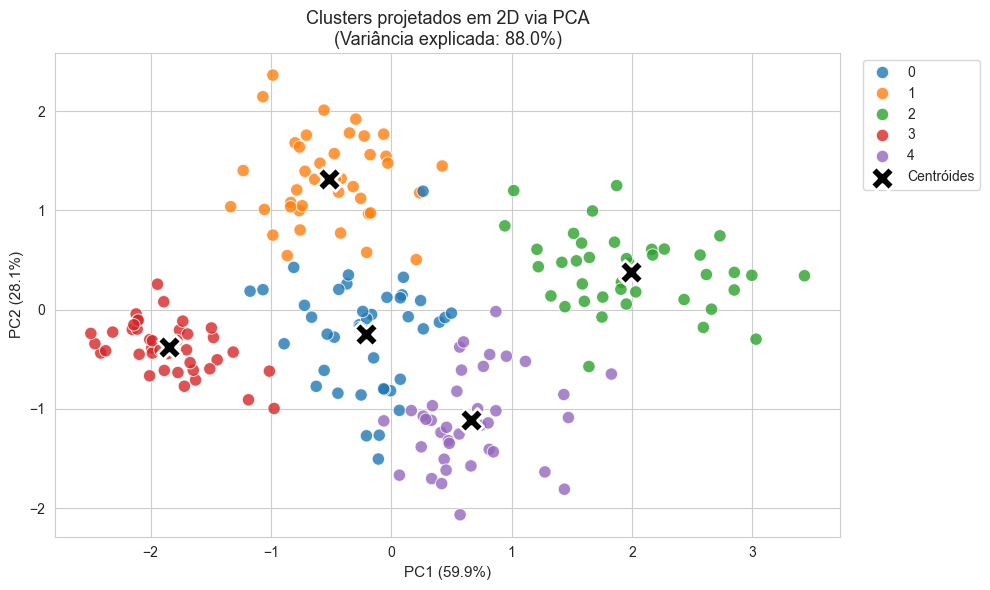

In [22]:
# Visualização com PCA: reduzir as 3 features para 2 dimensões para enxergar a separação geral
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clientes_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=clientes["Cluster"],
    palette="tab10",
    s=80, alpha=0.8, edgecolor="white"
)

# Projetar os centróides no espaço PCA
centroids_pca = pca.transform(modelo_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=300, edgecolor="white", linewidth=2,
            label="Centróides")

plt.title(f"Clusters projetados em 2D via PCA\n"
          f"(Variância explicada: {pca.explained_variance_ratio_.sum():.1%})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Por que usamos PCA aqui?** Como temos 3 features, não dá para plotar tudo em 2D diretamente. O PCA encontra as 2 "direções" que mais preservam a variância dos dados — assim conseguimos visualizar a separação dos clusters em uma única figura.

## 10.8 Entregando o resultado para o negócio

Em um cenário real, você entregaria:
1. Um **CSV** com os clientes rotulados (`ClienteID`, `Cluster`, `Persona`).
2. Um **relatório** descrevendo cada persona e recomendações de campanha.
3. Um **modelo treinado** (com `joblib.dump`) para classificar **novos clientes** que entrarem na base.

In [23]:
# Mapeamento de clusters para personas (você ajustaria os IDs após inspecionar o heatmap)
# Aqui criamos um mapeamento automático baseado nas características de cada cluster
def nomear_persona(row):
    renda, score = row["Renda_Anual_kUSD"], row["Score_Gastos"]
    if renda > 70 and score > 65:
        return "Alvo Ouro"
    elif renda > 70 and score < 40:
        return "Poupador Premium"
    elif renda < 45 and score > 65:
        return "Impulsivo"
    elif renda < 45 and score < 40:
        return "Econômico"
    else:
        return "Mainstream"

# Aplicando no perfil médio dos clusters
mapa_personas = perfil_clusters.apply(nomear_persona, axis=1).to_dict()
clientes["Persona"] = clientes["Cluster"].map(mapa_personas)

print("📦 Amostra do resultado final:\n")
print(clientes[["ClienteID", "Idade", "Renda_Anual_kUSD", "Score_Gastos", "Cluster", "Persona"]].head(10))

print("\n📊 Personas atribuídas:")
print(clientes["Persona"].value_counts())


📦 Amostra do resultado final:

   ClienteID  Idade  Renda_Anual_kUSD  Score_Gastos  Cluster           Persona
0          1     45              81.7            18        2  Poupador Premium
1          2     40              42.5            17        4         Econômico
2          3     40              37.9            11        4         Econômico
3          4     31              68.0            99        1         Alvo Ouro
4          5     32              86.2            77        1         Alvo Ouro
5          6     54              90.3            10        2  Poupador Premium
6          7     26              20.9            85        3         Impulsivo
7          8     39              65.1            50        0        Mainstream
8          9     58              54.8            58        4         Econômico
9         10     35              32.5            72        3         Impulsivo

📊 Personas atribuídas:
Persona
Alvo Ouro           41
Mainstream          41
Impulsivo           40

In [24]:
# Para classificar um NOVO cliente que chega depois
def classificar_novo_cliente(idade, renda_kusd, score_gastos):
    """Recebe os dados de um cliente novo e devolve seu cluster + persona."""
    novo = np.array([[idade, renda_kusd, score_gastos]])
    novo_scaled = scaler.transform(novo)        # importante: usar o MESMO scaler já fitted
    cluster = int(modelo_final.predict(novo_scaled)[0])
    persona = mapa_personas[cluster]
    return cluster, persona

# Exemplo
cluster_novo, persona_nova = classificar_novo_cliente(idade=29, renda_kusd=95, score_gastos=85)
print(f"Cliente novo (29 anos, $95k de renda, score 85)")
print(f"  → Cluster: {cluster_novo}")
print(f"  → Persona: {persona_nova}")


Cliente novo (29 anos, $95k de renda, score 85)
  → Cluster: 1
  → Persona: Alvo Ouro


---

## 🎓 Resumo da aula

| Tópico | Mensagem-chave |
|---|---|
| **Algoritmo** | Atribuir → recalcular → repetir até convergir |
| **K-Means++** | Inicialização inteligente; já é o padrão do sklearn |
| **Escolha do k** | Cotovelo (qualitativo) + Silhueta (quantitativo) + Negócio |
| **Limitações** | Clusters esféricos, tamanhos similares, sensível a outliers e escala |
| **Pré-processamento** | **Sempre padronize** com `StandardScaler` |
| **Interpretação** | Um cluster sem nome é inútil — descreva cada persona em linguagem de negócio |

## 📚 Para aprofundar
- **DBSCAN** — para clusters de formato arbitrário e detecção de outliers.
- **Gaussian Mixture Models (GMM)** — versão "soft" e probabilística do K-Means.
- **Hierarchical Clustering** — gera dendrogramas; útil quando você quer várias granularidades.
- **t-SNE / UMAP** — para visualizar clusters em alta dimensão.

## 🏋️ Exercícios propostos
1. Refaça a segmentação usando **apenas 2 features** (Renda e Score). Os clusters mudam? Por quê?
2. **Adicione outliers** ao dataset (ex: 5 clientes com renda 200k) e veja como o K-Means reage.
3. Compare o resultado do K-Means com o do **DBSCAN** (`from sklearn.cluster import DBSCAN`).
4. **Desafio:** baixe o dataset real "Mall Customer Segmentation" do Kaggle e refaça toda a análise.

---

🎉 **Boa aula! Dúvidas → mãos ao código.**


### ex1

In [25]:
clientes.columns

Index(['ClienteID', 'Idade', 'Renda_Anual_kUSD', 'Score_Gastos', 'Cluster',
       'Persona'],
      dtype='object')

In [26]:
test_features = ['Renda_Anual_kUSD', 'Score_Gastos']
clientes[test_features]

,Renda_Anual_kUSD,Score_Gastos
0,81.7,18
1,42.5,17
2,37.9,11
3,68.0,99
4,86.2,77
...,...,...
195,105.3,6
196,43.2,30
197,82.9,20
198,55.4,61


In [27]:
clientes_copia = clientes.copy()

In [28]:

# Selecionar apenas as features numéricas relevantes
X_clientes_test = clientes_copia[test_features].values
X_clientes_test
# Padronizar
scaler = StandardScaler()
X_clientes_scaled_test = scaler.fit_transform(X_clientes_test)

# Conferindo: cada feature padronizada tem média ~0 e desvio ~1
df_check = pd.DataFrame(X_clientes_scaled_test, columns=test_features)
print("Após padronização:")
print(df_check.describe().round(3).loc[["mean", "std"]])


Após padronização:
      Renda_Anual_kUSD  Score_Gastos
mean             0.000         0.000
std              1.003         1.003


In [29]:
len(clientes)

200

In [30]:
K_FINAL = 5

modelo_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE
)

clientes_copia["Cluster"] = modelo_final.fit_predict(X_clientes_scaled_test)

print(f"Distribuição de clientes por cluster:\n")
print(clientes["Cluster"].value_counts().sort_index())


Distribuição de clientes por cluster:

Cluster
0    41
1    41
2    39
3    40
4    39
Name: count, dtype: int64


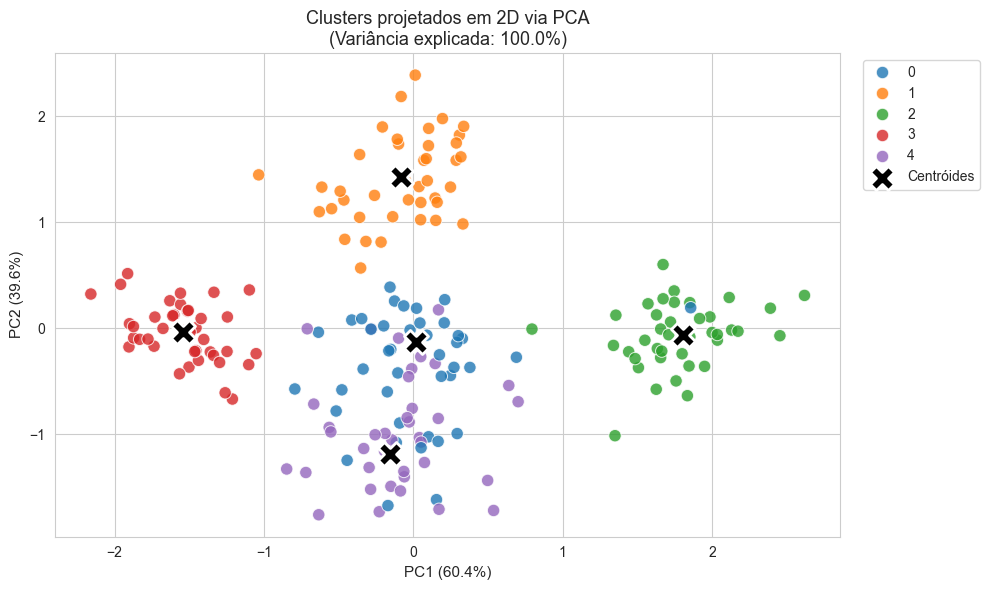

In [31]:
# Visualização com PCA: reduzir as 3 features para 2 dimensões para enxergar a separação geral
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clientes_scaled_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=clientes["Cluster"],
    palette="tab10",
    s=80, alpha=0.8, edgecolor="white"
)

# Projetar os centróides no espaço PCA
centroids_pca = pca.transform(modelo_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=300, edgecolor="white", linewidth=2,
            label="Centróides")

plt.title(f"Clusters projetados em 2D via PCA\n"
          f"(Variância explicada: {pca.explained_variance_ratio_.sum():.1%})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Sim, os clusters mudam quando usa apenas Renda e Score, porque o algoritmo passa a considerar somente essas duas variáveis no cálculo das distâncias entre os clientes. Ao reduzir o número de features, parte das informações sobre o comportamento dos clientes é perdida, fazendo com que os agrupamentos se tornem diferentes e mais simplificados. Fica ate mais facil de visualizar, mas dessa forma perde um contexto que poderia se importante para o conhecimento do dominio

### ex2


In [32]:
outliers = pd.DataFrame({
    "Idade":[1000, 1, 100, 2, -1],
    "Renda_Anual_kUSD": [200000, 210000, 220000, 230000, 250000],
    "Score_Gastos": [50, 55, 60, 58, 52]
})

# Adicionando ao dataset original
clientes_out = pd.concat([clientes, outliers], ignore_index=True)

In [33]:
clientes_out

,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos,Cluster,Persona
0,1.0,45,81.7,18,2.0,Poupador Premium
1,2.0,40,42.5,17,4.0,Econômico
2,3.0,40,37.9,11,4.0,Econômico
3,4.0,31,68.0,99,1.0,Alvo Ouro
4,5.0,32,86.2,77,1.0,Alvo Ouro
...,...,...,...,...,...,...
200,NaN,1000,200000.0,50,NaN,NaN
201,NaN,1,210000.0,55,NaN,NaN
202,NaN,100,220000.0,60,NaN,NaN
203,NaN,2,230000.0,58,NaN,NaN


In [34]:
cliente_ex2 = clientes_out.copy()

In [35]:

# Selecionar apenas as features numéricas relevantes
X_clientes_ex2 = cliente_ex2[features].values
X_clientes_ex2
# Padronizar
scaler = StandardScaler()
X_clientes_scaled_ex2 = scaler.fit_transform(X_clientes_ex2)

# Conferindo: cada feature padronizada tem média ~0 e desvio ~1
df_check = pd.DataFrame(X_clientes_ex2, columns=features)
print("Após padronização:")
print(df_check.describe().round(3).loc[["mean", "std"]])


Após padronização:
       Idade  Renda_Anual_kUSD  Score_Gastos
mean  41.693          5473.406        52.951
std   68.540         34425.213        26.023


In [36]:
K_FINAL = 5

modelo_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE
)

cliente_ex2["Cluster"] = modelo_final.fit_predict(X_clientes_scaled_ex2)

print(f"Distribuição de clientes por cluster:\n")
print(cliente_ex2["Cluster"].value_counts().sort_index())


Distribuição de clientes por cluster:

Cluster
0    63
1     4
2    81
3     1
4    56
Name: count, dtype: int64


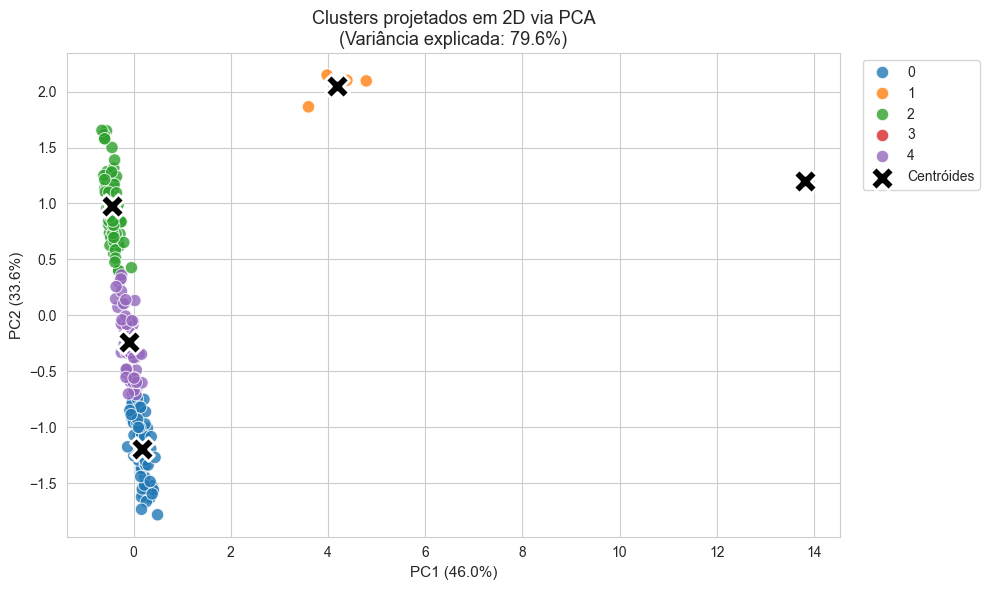

In [37]:
# Visualização com PCA: reduzir as 3 features para 2 dimensões para enxergar a separação geral
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clientes_scaled_ex2)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=cliente_ex2["Cluster"],
    palette="tab10",
    s=80, alpha=0.8, edgecolor="white"
)

# Projetar os centróides no espaço PCA
centroids_pca = pca.transform(modelo_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=300, edgecolor="white", linewidth=2,
            label="Centróides")

plt.title(f"Clusters projetados em 2D via PCA\n"
          f"(Variância explicada: {pca.explained_variance_ratio_.sum():.1%})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Nossa ao adicionar outliers ao dataset, o K-Means sofreu alterações significativas nos centróides e nos agrupamentos. Isso ocorre porque o algoritmo é baseado em ""médias"" e distâncias euclidianas, sendo altamente sensível a valores extremos. Os outliers podem puxar os centróides, deformar os clusters ou até criar grupos específicos apenas para esses pontos extremos.

### ex3

In [38]:
clientes

,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos,Cluster,Persona
0,1,45,81.7,18,2,Poupador Premium
1,2,40,42.5,17,4,Econômico
2,3,40,37.9,11,4,Econômico
3,4,31,68.0,99,1,Alvo Ouro
4,5,32,86.2,77,1,Alvo Ouro
...,...,...,...,...,...,...
195,196,66,105.3,6,2,Poupador Premium
196,197,31,43.2,30,0,Mainstream
197,198,71,82.9,20,2,Poupador Premium
198,199,23,55.4,61,0,Mainstream


In [39]:
from sklearn.cluster import DBSCAN

# DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clientes["Cluster_DBSCAN"] = dbscan.fit_predict(X_clientes_scaled)

In [40]:
clientes.describe()

,ClienteID,Idade,Renda_Anual_kUSD,Score_Gastos,Cluster,Cluster_DBSCAN
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,37.225000,60.241500,52.900000,1.975000,1.400000
std,57.879185,11.762489,26.811657,26.339683,1.419312,1.591434
min,1.000000,18.000000,15.000000,6.000000,0.000000,-1.000000
25%,50.750000,28.000000,34.625000,29.750000,1.000000,0.000000
50%,100.500000,36.000000,57.650000,52.000000,2.000000,2.000000
75%,150.250000,45.000000,85.825000,77.250000,3.000000,3.000000
max,200.000000,71.000000,115.600000,99.000000,4.000000,5.000000


In [41]:
clientes.columns

Index(['ClienteID', 'Idade', 'Renda_Anual_kUSD', 'Score_Gastos', 'Cluster',
       'Persona', 'Cluster_DBSCAN'],
      dtype='object')

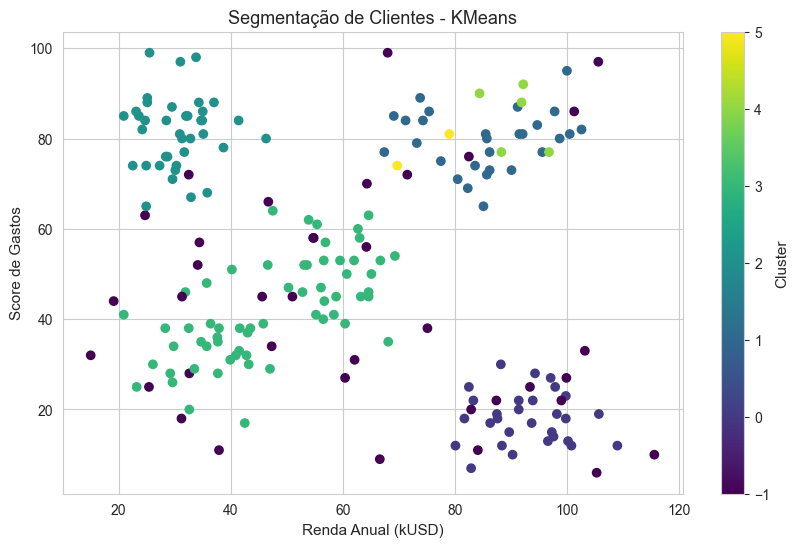

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    clientes["Renda_Anual_kUSD"],
    clientes["Score_Gastos"],
    c=clientes["Cluster_DBSCAN"],
    cmap="viridis"
)

plt.xlabel("Renda Anual (kUSD)")
plt.ylabel("Score de Gastos")
plt.title("Segmentação de Clientes - KMeans")

plt.colorbar(scatter, label="Cluster")

plt.show()

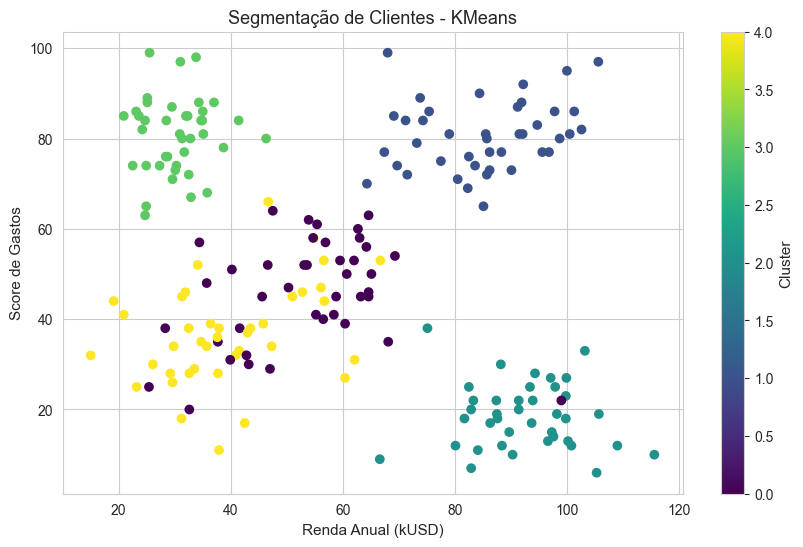

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    clientes["Renda_Anual_kUSD"],
    clientes["Score_Gastos"],
    c=clientes["Cluster"],
    cmap="viridis"
)

plt.xlabel("Renda Anual (kUSD)")
plt.ylabel("Score de Gastos")
plt.title("Segmentação de Clientes - KMeans")

plt.colorbar(scatter, label="Cluster")

plt.show()

O K-Means e o DBSCAN produzem resultados diferentes porque utilizam estratégias distintas de agrupamento. O K-Means cria clusters com base na distância até centróides e exige a definição prévia do número de grupos, sendo sensível a outliers. Já o DBSCAN agrupa os dados com base na densidade de pontos, identificando automaticamente regiões densas e tratando pontos isolados como ruído. Assim, o DBSCAN tende a lidar um pouco melhor com outliers e formatos irregulares de clusters, enquanto o K-Means funciona melhor em grupos mais compactos e bem definidos.

### DESAFIO  

In [44]:
import os 


In [45]:
current_path = os.getcwd()

In [46]:
excel_path = current_path+"/Mall_Customers.csv"
df_mall = pd.read_csv(excel_path)
df_mall

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [47]:
df_mall.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [48]:
df_mall.isna().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

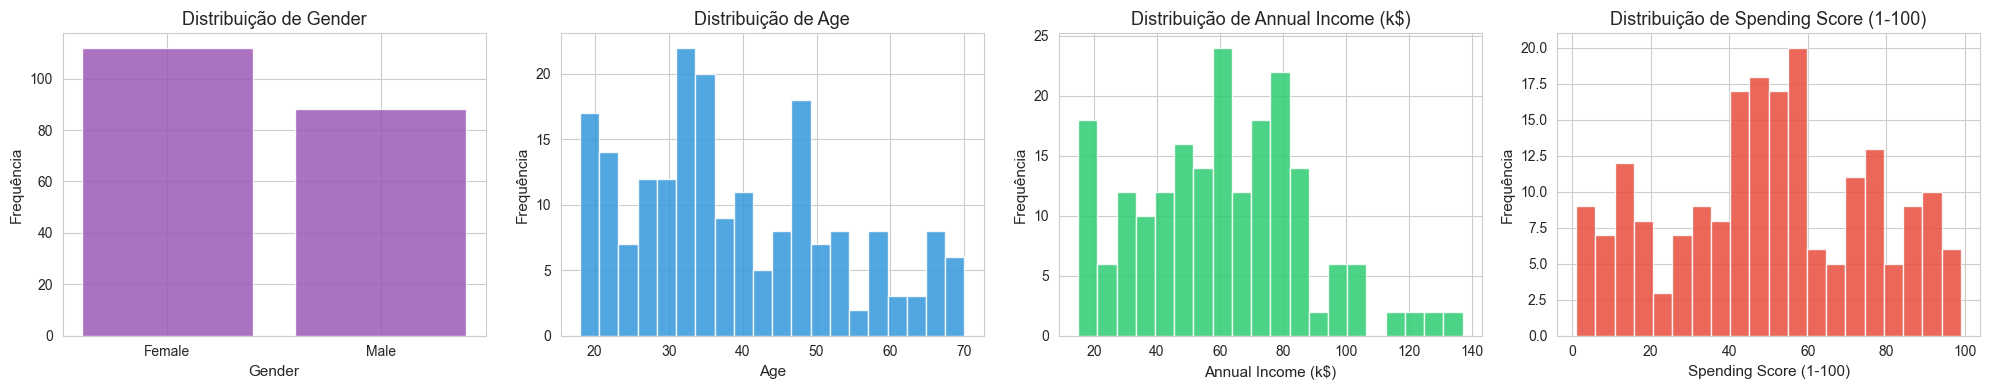

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
features_mall = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]
cores = ["#9b59b6", "#3498db", "#2ecc71", "#e74c3c"]

for ax, feat, cor in zip(axes, features_mall, cores):
    if df_mall[feat].dtype == "object":
        counts = df_mall[feat].value_counts()
        ax.bar(counts.index, counts.values, color=cor, edgecolor="white", alpha=0.85)
    else:
        ax.hist(df_mall[feat], bins=20, color=cor, edgecolor="white", alpha=0.85)
    ax.set_title(f"Distribuição de {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [50]:
df_mall["Gender"] = df_mall["Gender"].map({"Male": 0, "Female": 1})

In [51]:
# Selecionar apenas as features numéricas relevantes
X_mall = df_mall[features_mall].values

# Padronizar
scaler = StandardScaler()
X_mall_scaled = scaler.fit_transform(X_mall)

# Conferindo: cada feature padronizada tem média ~0 e desvio ~1
df_check = pd.DataFrame(X_mall_scaled, columns=features_mall)
print("Após padronização:")
print(df_check.describe().round(3).loc[["mean", "std"]])

Após padronização:
      Gender    Age  Annual Income (k$)  Spending Score (1-100)
mean  -0.000 -0.000              -0.000                  -0.000
std    1.003  1.003               1.003                   1.003


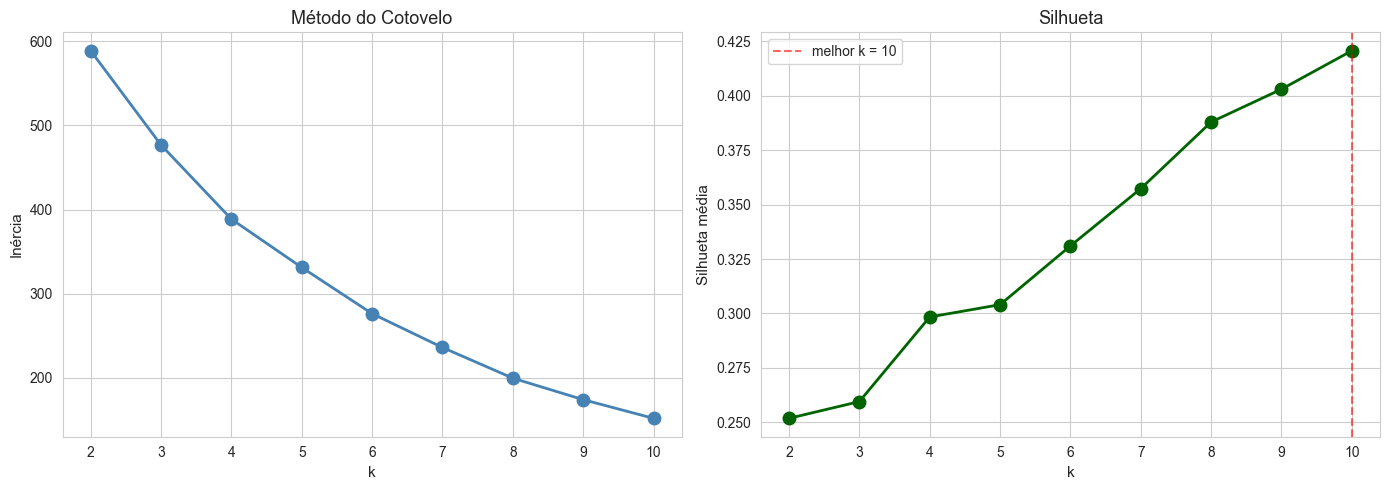


🏆 Sugestão dos métodos: k = 10


In [52]:
inertias_lab = []
sils_lab = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X_mall_scaled)
    inertias_lab.append(km.inertia_)
    sils_lab.append(silhouette_score(X_mall_scaled, labels_k))

# Plot lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ks, inertias_lab, "o-", color="steelblue", linewidth=2, markersize=9)
axes[0].set_title("Método do Cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")
axes[0].set_xticks(list(ks))

axes[1].plot(ks, sils_lab, "o-", color="darkgreen", linewidth=2, markersize=9)
best_k_lab = list(ks)[int(np.argmax(sils_lab))]
axes[1].axvline(best_k_lab, color="red", linestyle="--", alpha=0.6,
                label=f"melhor k = {best_k_lab}")
axes[1].set_title("Silhueta")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhueta média")
axes[1].set_xticks(list(ks))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n🏆 Sugestão dos métodos: k = {best_k_lab}")


In [53]:
K_FINAL = 7

modelo_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=10,
    random_state=RANDOM_STATE
)

df_mall["Cluster"] = modelo_final.fit_predict(X_mall_scaled)

print(f"Distribuição de clientes por cluster:\n")
print(df_mall["Cluster"].value_counts().sort_index())


Distribuição de clientes por cluster:

Cluster
0    40
1    24
2    37
3    18
4    33
5    22
6    26
Name: count, dtype: int64


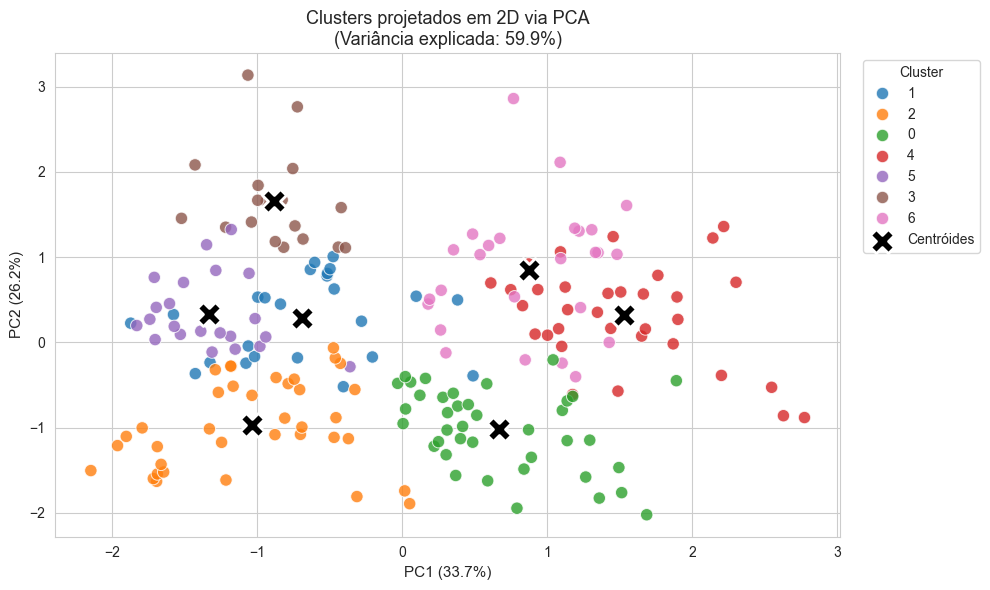

In [54]:
# Visualização com PCA: reduzir as 4 features para 2 dimensões
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_mall_scaled)  # usar dados escalados

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_mall["Cluster"].astype(str),   # string para cores discretas
    palette="tab10",
    s=80, alpha=0.8, edgecolor="white"
)

# Projetar os centróides no espaço PCA
centroids_pca = pca.transform(modelo_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c="black", marker="X", s=300, edgecolor="white", linewidth=2,
            label="Centróides")

plt.title(f"Clusters projetados em 2D via PCA\n"
          f"(Variância explicada: {pca.explained_variance_ratio_.sum():.1%})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [55]:
df_mall.groupby("Cluster")[["Gender","Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,1.0,50.9,49.2,39.7
1,0.0,25.2,41.2,60.9
2,1.0,25.9,42.2,57.5
3,0.0,33.3,87.1,82.7
4,0.0,56.7,53.7,35.9
5,1.0,32.5,85.3,80.6
6,0.5,37.8,91.5,16.1


In [56]:
features_interp = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]


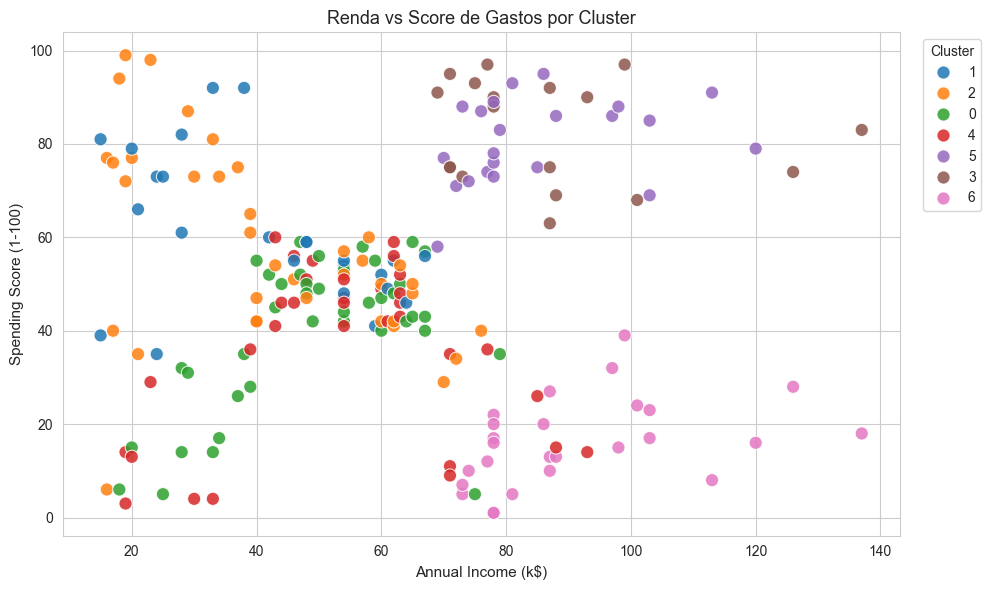

In [57]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_mall,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue=df_mall["Cluster"].astype(str),
    palette="tab10",
    s=90, alpha=0.85, edgecolor="white"
)
plt.title("Renda vs Score de Gastos por Cluster")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

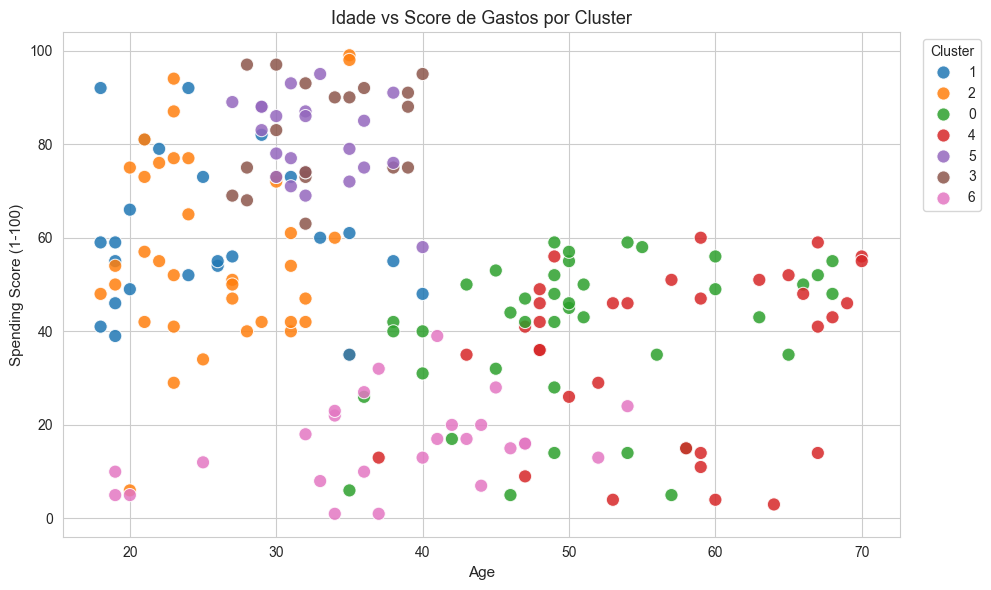

In [58]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_mall,
    x="Age",
    y="Spending Score (1-100)",
    hue=df_mall["Cluster"].astype(str),
    palette="tab10",
    s=90, alpha=0.85, edgecolor="white"
)
plt.title("Idade vs Score de Gastos por Cluster")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

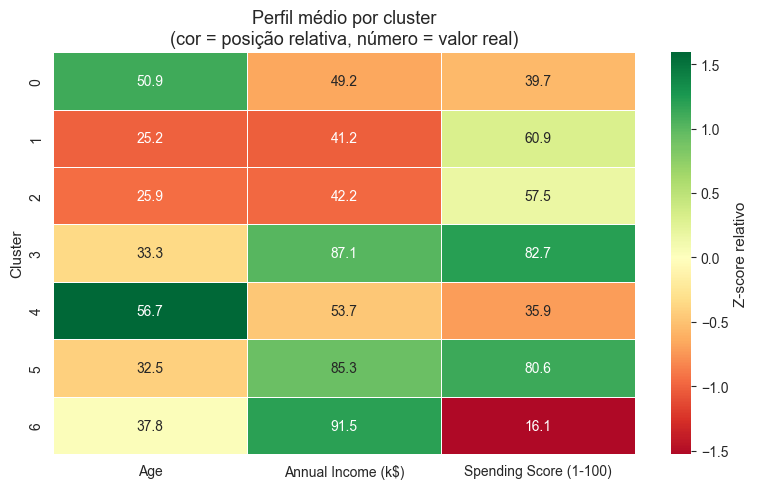

In [59]:
perfil = df_mall.groupby("Cluster")[features_interp].mean()
perfil_z = (perfil - perfil.mean()) / perfil.std()

plt.figure(figsize=(8, 5))
sns.heatmap(
    perfil_z,
    annot=perfil.round(1).values,
    fmt=".1f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Z-score relativo"}
)
plt.title("Perfil médio por cluster\n(cor = posição relativa, número = valor real)")
plt.tight_layout()
plt.show()

C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_22228\1675953300.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mall, x="Cluster", y=feat, palette="tab10", ax=ax)
C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_22228\1675953300.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mall, x="Cluster", y=feat, palette="tab10", ax=ax)
C:\Users\henrique.cordeiro\AppData\Local\Temp\ipykernel_22228\1675953300.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mall, x="Cluster", y=feat, palette="tab10", ax

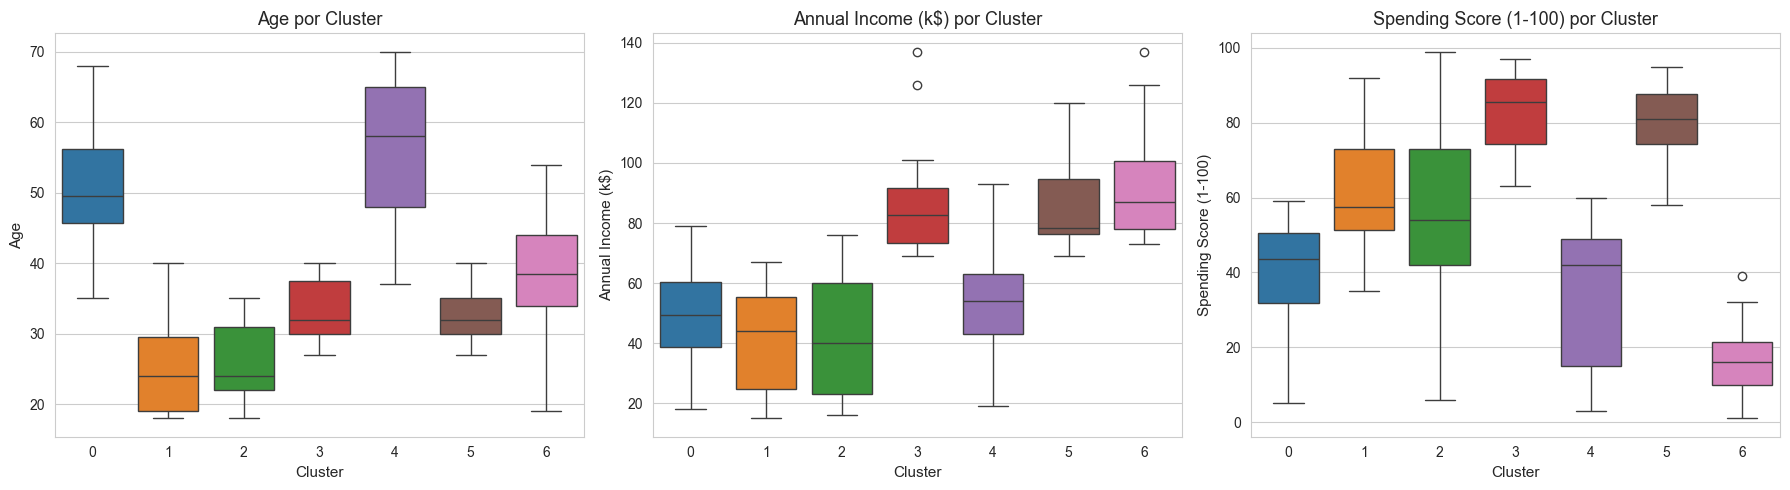

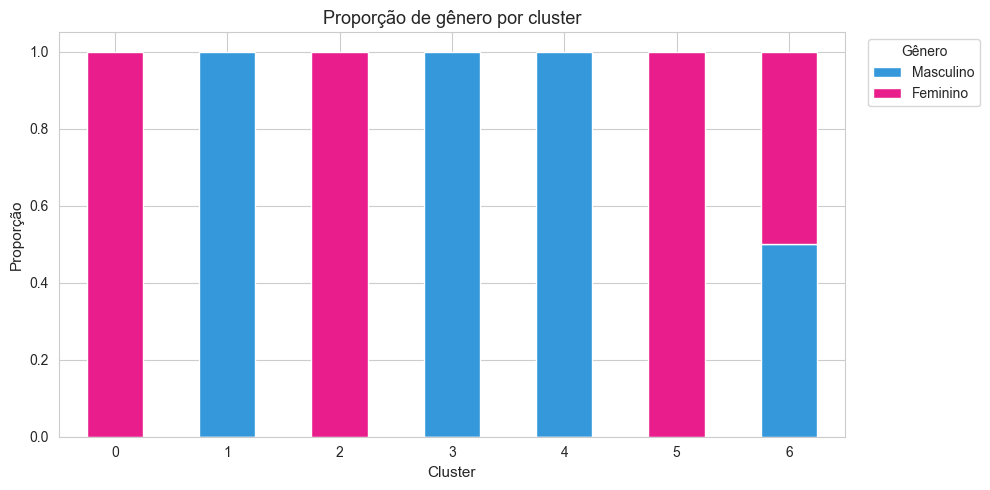

In [60]:
# ── 5. Boxplot: distribuição de cada feature por cluster ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, features_interp):
    sns.boxplot(data=df_mall, x="Cluster", y=feat, palette="tab10", ax=ax)
    ax.set_title(f"{feat} por Cluster")
plt.tight_layout()
plt.show()

# ── 6. Proporção de gênero por cluster ────────────────────────────────────────
genero_cluster = df_mall.groupby("Cluster")["Gender"].value_counts(normalize=True).unstack()
genero_cluster.columns = ["Masculino", "Feminino"]
genero_cluster.plot(kind="bar", stacked=True, figsize=(10, 5),
                    color=["#3498db", "#e91e8c"], edgecolor="white")
plt.title("Proporção de gênero por cluster")
plt.xlabel("Cluster")
plt.ylabel("Proporção")
plt.xticks(rotation=0)
plt.legend(title="Gênero", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [61]:
features_interp = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
perfil = df_mall.groupby("Cluster")[features_interp].mean().round(1)
perfil["N_Clientes"] = df_mall["Cluster"].value_counts().sort_index()
perfil["% Feminino"] = (
    df_mall.groupby("Cluster")["Gender"].mean() * 100
).round(0).astype(int)
print(perfil)

          Age  Annual Income (k$)  Spending Score (1-100)  N_Clientes  \
Cluster                                                                 
0        50.9                49.2                    39.7          40   
1        25.2                41.2                    60.9          24   
2        25.9                42.2                    57.5          37   
3        33.3                87.1                    82.7          18   
4        56.7                53.7                    35.9          33   
5        32.5                85.3                    80.6          22   
6        37.8                91.5                    16.1          26   

         % Feminino  
Cluster              
0               100  
1                 0  
2               100  
3                 0  
4                 0  
5               100  
6                50  


In [62]:
def nomear_persona_mall(row):
    age   = row["Age"]
    inc   = row["Annual Income (k$)"]
    score = row["Spending Score (1-100)"]

    if inc >= 80 and score >= 70:
        return "Premium"           # Renda alta + gasto alto → alvo ouro
    elif inc >= 80 and score < 40:
        return "Executivo Poupador" # Renda alta + gasto baixo → seletivo
    elif inc < 45 and score >= 65:
        return "Impulsivo"          # Renda baixa + gasto alto → compra por emoção
    elif inc < 45 and score < 40:
        return "Econômico"          # Renda baixa + gasto baixo → cauteloso
    elif age < 30 and score >= 55:
        return "Jovem Aspiracional" # Jovem com gasto moderado/alto
    elif age >= 50:
        return "Maduro Estável"     # Mais velho com perfil moderado
    else:
        return "Mainstream"         # Perfil médio em tudo


In [63]:
mapa_personas = perfil.apply(nomear_persona_mall, axis=1).to_dict()
df_mall["Persona"] = df_mall["Cluster"].map(mapa_personas)


In [64]:
mapa_personas

{0: 'Maduro Estável',
 1: 'Jovem Aspiracional',
 2: 'Jovem Aspiracional',
 3: 'Premium',
 4: 'Maduro Estável',
 5: 'Premium',
 6: 'Executivo Poupador'}

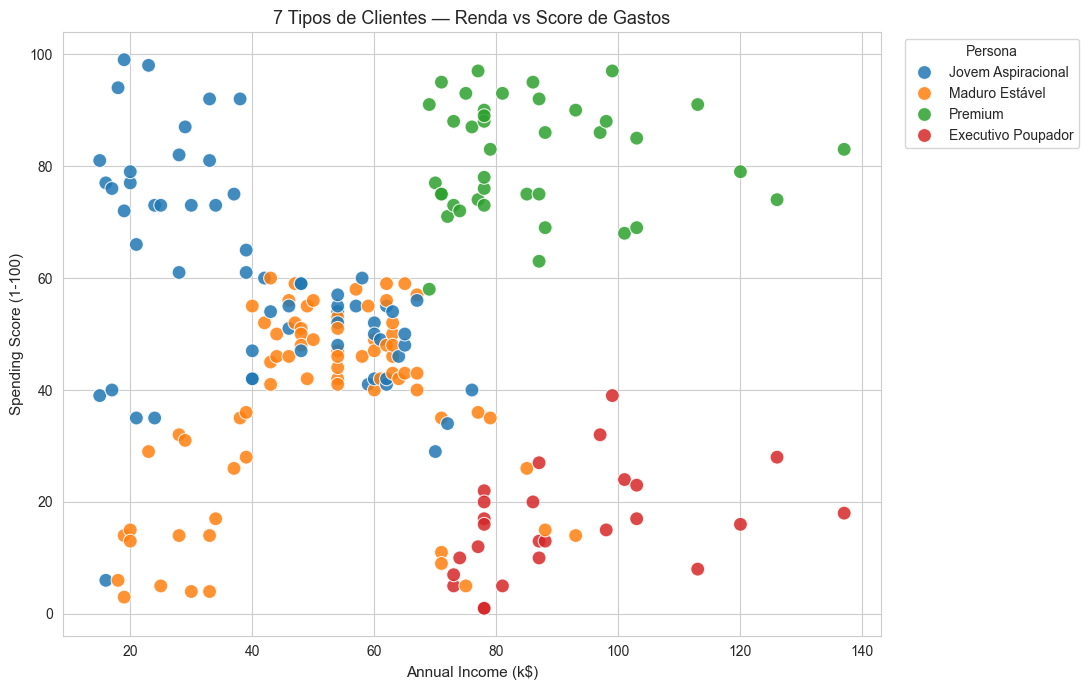

In [65]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_mall,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Persona",
    palette="tab10",
    s=100, alpha=0.85, edgecolor="white"
)
plt.title("7 Tipos de Clientes — Renda vs Score de Gastos")
plt.legend(title="Persona", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()